In [53]:
# Calculate F function, for hyperfine shift calculation per Jochemsen

In [54]:
# Imports
import sys
sys.path.append("../src/")
sys.path.append("../src/AtomicTrit")

from AtomicTrit import elastic
from AtomicTrit import constants
from AtomicTrit import potentials
import numpy as np
import pylab as plt
import pandas as pd


In [55]:
#====================
# HeH potentials
#====================
path="../src/AtomicTrit/"
datLong=pd.read_csv(path+"InputData/HeH_MeyerFromhold.csv")
datShort=pd.read_csv(path+"InputData/HeH_ShortCorrection.csv")


In [56]:
#Quick access constants

kB   = 8.617e-5 # in eV K^-1
bohr = constants.BohrInAng/constants.hcInEVAngstrom


In [57]:
#Here are the masses and atom names we will need
muH=constants.HydrogenConstants.mu
m4He_ov_mH=4.0026/1.008
m3He_ov_mH=3.0160/1.008
mT_ov_mH=constants.TritiumConstants.mu/constants.HydrogenConstants.mu
mD_ov_mH=2.0141/1.008


HAtoms=["H","D","T"]
HeAtoms=["3He","4He"]

HMasses=[1,2.0141/1.008,constants.TritiumConstants.mu/constants.HydrogenConstants.mu]
HeMasses=[3.0160/1.008,4.0026/1.008]

MuBySpecies={}
for Hi in range(0,len(HMasses)):
    for Hei in range(0,len(HeMasses)):
        muC=2.*HMasses[Hi]*HeMasses[Hei]/(HMasses[Hi]+HeMasses[Hei])
        name= HAtoms[Hi]+"-"+HeAtoms[Hei]
        MuBySpecies[name]=muC



In [58]:
#Table of reduced masses
print(MuBySpecies)

{'H-3He': 1.4990059642147118, 'H-4He': 1.597652975691534, 'D-3He': 2.396101500711747, 'D-4He': 2.6584856870599056, 'T-3He': 2.993162160100278, 'T-4He': 3.4140852245876068}


In [59]:
#Here we make the potential functions

interpMF= interp1d(datLong.R*bohr,datLong.Total*constants.HartreeInEV*1e-6, kind='cubic', bounds_error=False,fill_value='extrapolate')

interpShort = interp1d(datShort.R*bohr,datShort.Modified*constants.HartreeInEV*1e-6, kind='cubic', bounds_error=False,fill_value='extrapolate')

def ExtendedMF(R):
    return potentials.VanDerWaalsExtension(R,interpMF,15*bohr)

def ModifiedMF(R):
    return potentials.CompositePotential(R, [interpShort, ExtendedMF], [0, 6.0 * bohr, 1e6])


In [60]:
# get the F function of Jochemsen, based on
#   E: collision energy in Kelvin
#   l: angular momentum
#   mu: reduced mass, as multiple of H-H reduced mass
#   rhos: max integration limit, in Angstrom
def GetF(E,l,mu,rhomax=500):
    muIn=mu*constants.HydrogenConstants.mu
    k_eV=np.sqrt(2*muIn*E*kB)
    rhos=np.linspace(1e-9, rhomax/constants.hcInEVAngstrom, 100)
    u=np.array(elastic.Wave_Function(rhos,k_eV,l, muIn, potential=ExtendedMF, int_type='Radau')[0])
    return u*np.sqrt((2*l+1)/(4*np.pi))

In [61]:

Channel="T-4He"           # scattering channel
ls = np.arange(0, 10, 1)  # partial waves up to 10
E=  1e-2                  # 10 mK
rhomax=500                # upper limit on distances, in Angstrom

rhos=np.linspace(0, rhomax, 100)
mu=MuBySpecies[Channel]

Fl=[]
for l in ls:
    Fl.append(GetF(E,l,mu))


(0.0, 500.0)

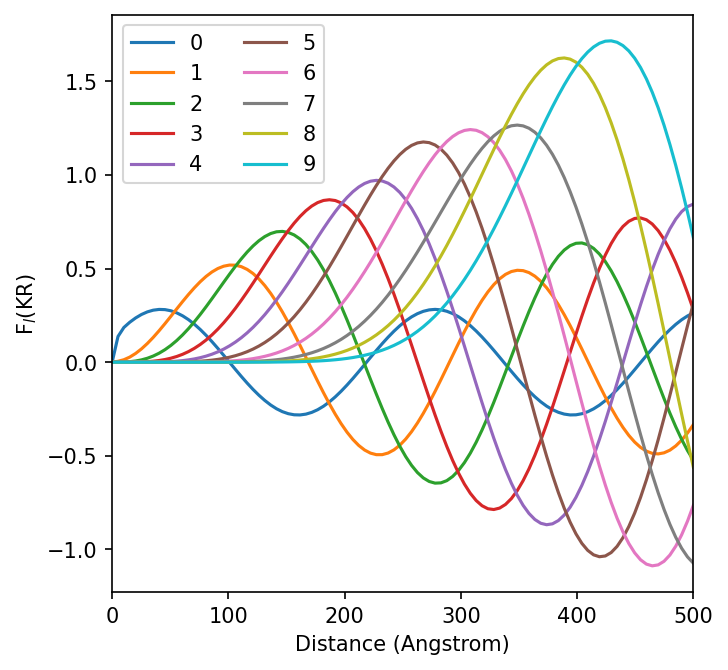

In [62]:
plt.figure(figsize=(5,5),dpi=150)
for l in ls:
    plt.plot(rhos,Fl[l],label=l)
plt.legend(loc='upper left',ncol=2)
plt.ylabel("F$_l$(KR)")
plt.xlabel("Distance (Angstrom)")
plt.xlim(0,rhomax)